# Lab 10 — OOD / Drift / Failure Evaluation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/overdued/world-model-spatial-intelligence-course/blob/main/labs/lab10_ood_drift_evaluation/notebook_en.ipynb)

**The course's reliability capstone experiment.** Training a world model is only the starting point: is it still reliable outside its training distribution?
This lab trains a Lab 2-style latent dynamics model on ID (in-distribution) data,
then systematically creates **distribution shift** (Mild / Strong OOD) and evaluates failure modes at four levels:

> **one-step error → multi-step drift → uncertainty proxy → planning / policy failure**

Finally it automatically builds a **Failure Gallery** (`assets/failure_gallery/`) that archives the most typical failure cases.

## 1. Motivation: why can't we look only at the one-step loss?

The metric most often reported when training a world model is the **one-step prediction error**. But at deployment the model does something completely different:

- **Multi-step rollout**: predictions are fed back into the model, and per-step errors pile up (**compounding error / drift**);
- **Planning / control**: the planner actively "games" the model, picking the action sequences where model error is largest (**model exploitation**);
- **OOD environments**: the real world's speed, friction, lighting and occlusion drift away from the training distribution at any time.

A model with a beautiful one-step loss can diverge completely after a 10-step rollout. The core teaching point of this lab:

> **Evaluating a world model cannot stop at the one-step loss; drift, compounding error and OOD robustness are what matter for deployment.**
> (This follows the evaluation framework of CIS6280 L23: accuracy → calibration → robustness → downstream utility.)

## 2. Setup

**Why this cell exists:** the only dependencies are PyTorch (CPU is enough), NumPy and Matplotlib, all preinstalled on Colab; anything missing locally is installed automatically.

In [1]:
# @title setup
import sys, subprocess

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["torch", "matplotlib"]:
    ensure(pkg)

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

%matplotlib inline
os.makedirs("assets/failure_gallery", exist_ok=True)
torch.manual_seed(0)
np.random.seed(0)
print("torch", torch.__version__, "| device: cpu")

torch 2.14.0+cu130 | device: cpu


## 3. Environment & Dataset: one world, three kinds of physics

We keep the moving-ball world from Labs 0/2 but expose all of its physics and observation parameters. Three experimental conditions:

| Condition | speed | friction | bounce | pixel noise | background | occluder bar |
|---|---|---|---|---|---|---|
| **ID** (training distribution) | 1.0 | 0.95 | 0.9 (elastic walls) | none | pure black | none |
| **Mild OOD** | ×1.5 | 0.95 | 0.9 | slight | slightly brighter | none |
| **Strong OOD** | ×3.0 | **1.05 (negative damping, speed is amplified)** | **0.15 (bounces turn sticky)** | strong | gray | **static occluder bar (never seen in training)** |

**Why:** distribution shift doesn't require a different dataset. The same simulator code with a different set of parameters is the cleanest controlled OOD experiment.

train (ID): (2000, 64, 64) | eval per condition: (640, 64, 64)


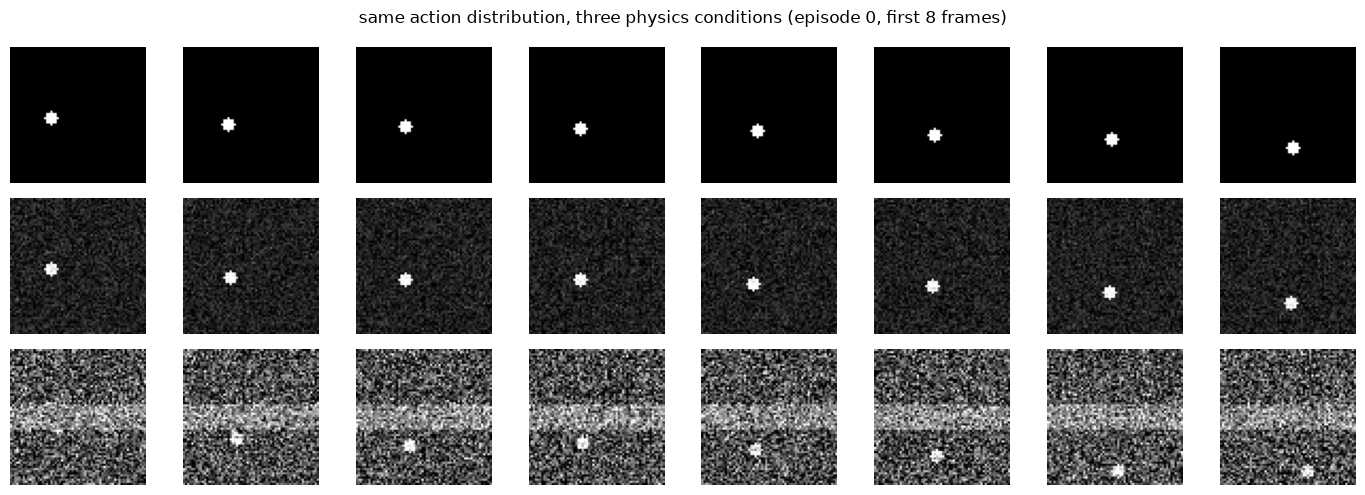

In [2]:
SIZE, DT = 64, 0.1

CONDITIONS = {
    "ID":     dict(speed=1.0, friction=0.95, bounce=0.9,  obs_noise=0.0,  background=0.0,  occlude=False),
    "Mild":   dict(speed=1.5, friction=0.95, bounce=0.9,  obs_noise=0.08, background=0.12, occlude=False),
    "Strong": dict(speed=3.0, friction=1.05, bounce=0.15, obs_noise=0.25, background=0.30, occlude=True),
}

class BallWorld:
    # parameterized bouncing-ball world (a slimmed-down Lab 0): white ball + optional background / noise / occlusion
    def __init__(self, speed=1.0, friction=0.95, bounce=0.9,
                 obs_noise=0.0, background=0.0, occlude=False, seed=0):
        self.speed, self.friction, self.bounce = speed, friction, bounce
        self.obs_noise, self.background, self.occlude = obs_noise, background, occlude
        self.rng = np.random.default_rng(seed)
        self.state = None                       # (x, y, vx, vy), normalized coordinates

    def reset(self, seed=None):
        if seed is not None:
            self.rng = np.random.default_rng(seed)
        x, y = self.rng.uniform(0.15, 0.85, size=2)
        vx, vy = self.rng.uniform(-0.5, 0.5, size=2)
        self.state = np.array([x, y, vx, vy])
        return self.render()

    def step(self, a):
        x, y, vx, vy = self.state
        vx = (vx + 2.0 * self.speed * a[0] * DT) * self.friction
        vy = (vy + 2.0 * self.speed * a[1] * DT) * self.friction
        x, y = x + vx * DT, y + vy * DT
        if x < 0: x, vx = -x, -vx * self.bounce
        if x > 1: x, vx = 2 - x, -vx * self.bounce
        if y < 0: y, vy = -y, -vy * self.bounce
        if y > 1: y, vy = 2 - y, -vy * self.bounce
        self.state = np.array([x, y, vx, vy])
        return self.render()

    def render(self):
        img = np.full((SIZE, SIZE), self.background, dtype=np.float32)
        px = int(np.clip(self.state[0], 0, 1) * (SIZE - 1))
        py = int(np.clip(self.state[1], 0, 1) * (SIZE - 1))
        yy, xx = np.mgrid[0:SIZE, 0:SIZE]
        img[(xx - px) ** 2 + (yy - py) ** 2 <= 3 ** 2] = 1.0
        if self.occlude:                        # static occluder bar: never appears in the training distribution
            img[26:38, :] = min(self.background + 0.25, 1.0)
        if self.obs_noise > 0:
            img = img + self.rng.normal(0, self.obs_noise, img.shape)
        return np.clip(img, 0, 1).astype(np.float32)

def simulate_dataset(cond="ID", n_ep=100, ep_len=20, seed=0):
    params = CONDITIONS[cond] if isinstance(cond, str) else cond
    rng = np.random.default_rng(seed)
    world = BallWorld(**params, seed=seed)
    frames, actions, positions, ep_ids = [], [], [], []
    for ep in range(n_ep):
        world.reset(seed=seed * 1000 + ep)
        for t in range(ep_len):
            a = rng.integers(-1, 2, size=2).astype(np.float32)   # a ∈ {-1,0,1}²
            frames.append(world.step(a))
            actions.append(a)
            positions.append(world.state[:2].copy())
            ep_ids.append(ep)
    return dict(frames=np.stack(frames), actions=np.stack(actions),
                positions=np.stack(positions), ep_ids=np.array(ep_ids))

# training data is ID only; one evaluation set per condition (same action distribution, different physics)
data_id = simulate_dataset("ID", n_ep=100, ep_len=20, seed=0)
eval_data = {c: simulate_dataset(c, n_ep=40, ep_len=16, seed=100) for c in CONDITIONS}
print("train (ID):", data_id["frames"].shape, "| eval per condition:", eval_data["ID"]["frames"].shape)

fig, axes = plt.subplots(3, 8, figsize=(14, 5))
for row, cond in enumerate(CONDITIONS):
    for col in range(8):
        axes[row, col].imshow(eval_data[cond]["frames"][col], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
    axes[row, 0].set_ylabel(cond, rotation=0, labelpad=35, fontsize=11)
plt.suptitle("same action distribution, three physics conditions (episode 0, first 8 frames)")
plt.tight_layout()
plt.show()

## 4. Build the Model: Encoder → Dynamics → Decoder

**Why this architecture:** exactly the same as Lab 2: a ConvEncoder compresses a 64×64 image into `z ∈ R^16`,
an MLP dynamics learns the residual transition `(z_t, a_t) → ẑ_{t+1}`, and a ConvDecoder decodes the latent back into an image.
This is the minimal skeleton of Dreamer / RSSM-style models; this lab cares about its **evaluation**, not its structure.

In [3]:
Z_DIM, A_DIM = 16, 2

class Encoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 4, 2, 1), nn.ReLU(),   # 64 -> 32
            nn.Conv2d(16, 32, 4, 2, 1), nn.ReLU(),  # 32 -> 16
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),  # 16 -> 8
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128), nn.ReLU(),
            nn.Linear(128, z_dim),
        )

    def forward(self, x):
        return self.net(x)

class Dynamics(nn.Module):
    def __init__(self, z_dim=Z_DIM, a_dim=A_DIM, h=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim + a_dim, h), nn.ReLU(),
            nn.Linear(h, h), nn.ReLU(),
            nn.Linear(h, z_dim),
        )

    def forward(self, z, a):
        return z + self.net(torch.cat([z, a], dim=-1))  # residual transition

class Decoder(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.fc = nn.Sequential(nn.Linear(z_dim, 128), nn.ReLU(), nn.Linear(128, 64 * 8 * 8), nn.ReLU())
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),  # 8 -> 16
            nn.ConvTranspose2d(32, 16, 4, 2, 1), nn.ReLU(),  # 16 -> 32
            nn.ConvTranspose2d(16, 1, 4, 2, 1),              # 32 -> 64, raw logits
        )

    def forward(self, z):
        return self.deconv(self.fc(z).view(-1, 64, 8, 8))  # logits; sigmoid for display only

enc, dyn, dec = Encoder(), Dynamics(), Decoder()
n_params = sum(p.numel() for m in (enc, dyn, dec) for p in m.parameters())
print(f"parameters: {n_params:,}  (tiny — CPU-friendly)")

parameters: 1,160,641  (tiny — CPU-friendly)


## 5. Train (ID data only)

**Why these two losses:** reconstruction (BCE) teaches the encoder a decodable representation; one-step latent prediction (MSE, stop-gradient) aligns the dynamics with the encoder's geometry. **From start to finish the model only ever sees ID physics**; all the Mild / Strong data later is its "unknown world".

1900 valid ID transitions


step  200/800  recon-BCE 0.2532  latent-pred(norm) 0.0000


step  400/800  recon-BCE 0.0139  latent-pred(norm) 0.1071


step  600/800  recon-BCE 0.0087  latent-pred(norm) 0.1103


step  800/800  recon-BCE 0.0083  latent-pred(norm) 0.1113
trained in 54.8s on CPU (ID data only)


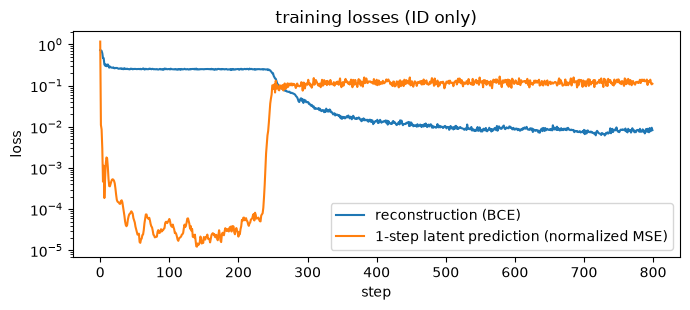

In [4]:
def prep(data):
    imgs = torch.from_numpy(data["frames"]).unsqueeze(1)      # (N, 1, 64, 64)
    acts = torch.from_numpy(data["actions"])                  # (N, 2)
    valid = np.where(data["ep_ids"][:-1] == data["ep_ids"][1:])[0]  # consecutive frames within an episode
    return imgs, acts, valid

imgs_id, acts_id, valid_id = prep(data_id)
print(f"{len(valid_id)} valid ID transitions")

params = list(enc.parameters()) + list(dyn.parameters()) + list(dec.parameters())
opt = torch.optim.Adam(params, lr=3e-3)
bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(10.0))  # ball pixels are rare positives
mse = nn.MSELoss()

BATCH, STEPS = 64, 800
rng = np.random.default_rng(0)
losses = []
t0 = time.time()
for step in range(STEPS):
    idx = torch.from_numpy(rng.choice(valid_id, size=BATCH, replace=False))
    x0, x1, a = imgs_id[idx], imgs_id[idx + 1], acts_id[idx]

    z0 = enc(x0)
    z1_target = enc(x1).detach()                 # stop-gradient target
    z1_pred = dyn(z0.detach(), a)                # enc is shaped by recon only

    loss_recon = bce(dec(z0), x0)
    loss_pred = mse(z1_pred, z1_target)
    loss = loss_recon + loss_pred

    opt.zero_grad(); loss.backward(); opt.step()
    losses.append((loss_recon.item(), loss_pred.item() / (z1_target.var().item() + 1e-8)))
    if (step + 1) % 200 == 0:
        print(f"step {step+1:4d}/{STEPS}  recon-BCE {loss_recon.item():.4f}  latent-pred(norm) {losses[-1][1]:.4f}")

print(f"trained in {time.time() - t0:.1f}s on CPU (ID data only)")

losses = np.array(losses)
plt.figure(figsize=(7, 3.2))
plt.plot(losses[:, 0], label="reconstruction (BCE)")
plt.plot(losses[:, 1], label="1-step latent prediction (normalized MSE)")
plt.xlabel("step"); plt.ylabel("loss"); plt.yscale("log")
plt.title("training losses (ID only)"); plt.legend(); plt.tight_layout(); plt.show()

## 6. Visualize: a health check on ID

**Why check ID first:** before evaluating OOD degradation, confirm the model is competent inside its training distribution: sharp reconstructions, on-target one-step predictions. Otherwise OOD errors cannot be attributed to distribution shift.

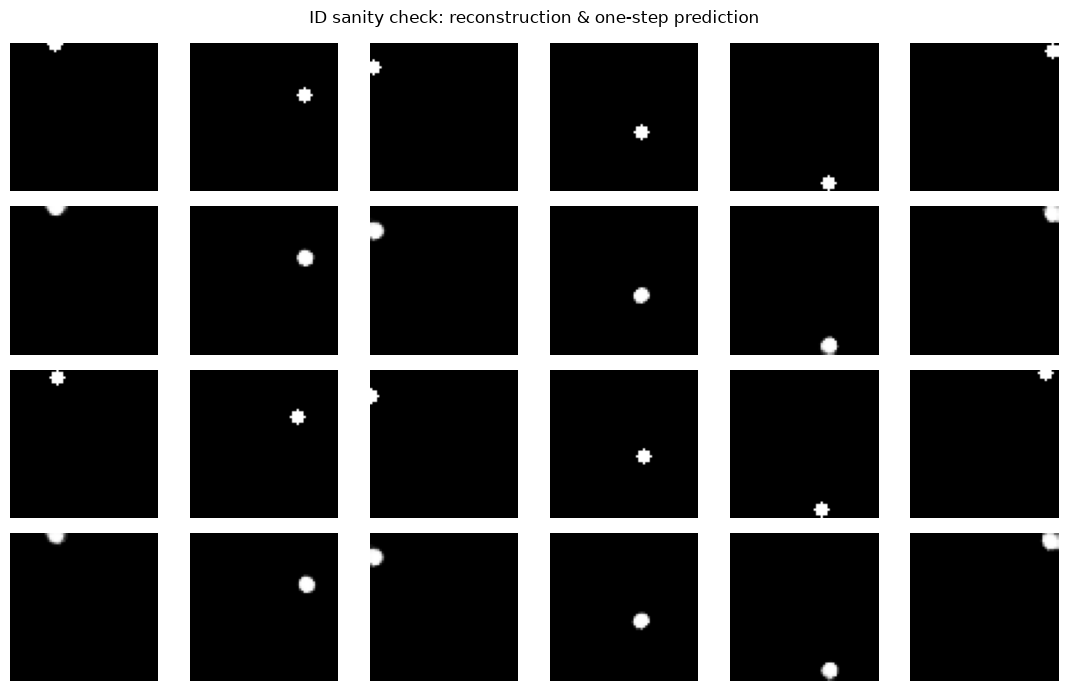

In [5]:
enc.eval(); dyn.eval(); dec.eval()
rng = np.random.default_rng(1)
idx = torch.from_numpy(rng.choice(valid_id, size=6, replace=False))

with torch.no_grad():
    z0 = enc(imgs_id[idx])
    recon = torch.sigmoid(dec(z0))
    z1_pred = dyn(z0, acts_id[idx])
    pred_next = torch.sigmoid(dec(z1_pred))

fig, axes = plt.subplots(4, 6, figsize=(11, 7))
rows = [imgs_id[idx, 0], recon[:, 0], imgs_id[idx + 1, 0], pred_next[:, 0]]
titles = ["input $x_t$", "reconstruction", "true $x_{t+1}$", "predicted $\hat{x}_{t+1}$"]
for r, (row_imgs, title) in enumerate(zip(rows, titles)):
    for c in range(6):
        axes[r, c].imshow(row_imgs[c], cmap="gray", vmin=0, vmax=1)
        axes[r, c].axis("off")
    axes[r, 0].set_ylabel(title, rotation=0, labelpad=95, fontsize=9)
plt.suptitle("ID sanity check: reconstruction & one-step prediction")
plt.tight_layout(); plt.show()

## 7. Evaluate I — one-step error: ID vs Mild vs Strong

The first question: **how sensitive is the one-step error to distribution shift?** For each evaluation set, compute the latent prediction MSE and the decoded pixel MSE on real pairs of consecutive frames.

Note that the input frames of Mild/Strong are themselves OOD (noise, background, occlusion), so this tests the robustness of the encoder and the dynamics at the same time.

ID       one-step latent MSE 55.9402   pixel MSE 0.00878
Mild     one-step latent MSE 69.1497   pixel MSE 0.02779
Strong   one-step latent MSE 227.8404   pixel MSE 0.19205


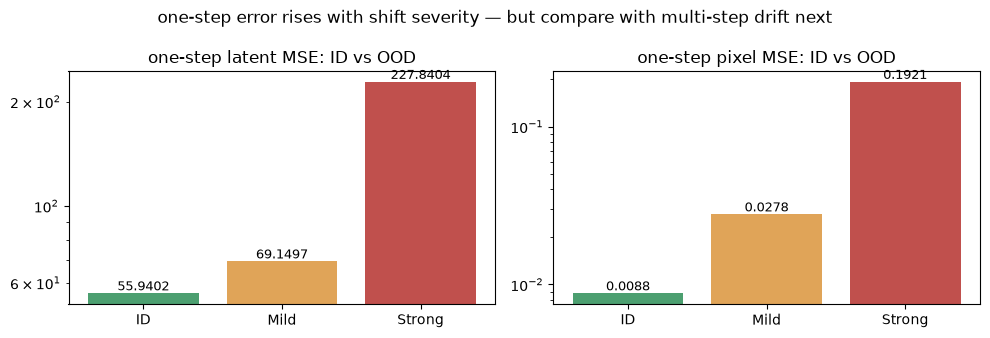

In [6]:
def one_step_eval(data):
    imgs, acts, valid = prep(data)
    with torch.no_grad():
        z0, z1 = enc(imgs[valid]), enc(imgs[valid + 1])
        z1_pred = dyn(z0, acts[valid])
        latent_err = ((z1_pred - z1) ** 2).mean(dim=1).numpy()
        pixel_err = ((torch.sigmoid(dec(z1_pred)) - imgs[valid + 1]) ** 2).mean(dim=(1, 2, 3)).numpy()
    return latent_err, pixel_err

one_step = {c: one_step_eval(eval_data[c]) for c in CONDITIONS}
for c in CONDITIONS:
    print(f"{c:7s}  one-step latent MSE {one_step[c][0].mean():.4f}   pixel MSE {one_step[c][1].mean():.5f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, k, name in zip(axes, [0, 1], ["latent MSE", "pixel MSE"]):
    means = [one_step[c][k].mean() for c in CONDITIONS]
    bars = ax.bar(CONDITIONS.keys(), means, color=["#4c9f70", "#e0a458", "#c0504d"])
    ax.set_title(f"one-step {name}: ID vs OOD"); ax.set_yscale("log")
    for b, m in zip(bars, means):
        ax.text(b.get_x() + b.get_width() / 2, m, f"{m:.4f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("one-step error rises with shift severity — but compare with multi-step drift next")
plt.tight_layout(); plt.show()

## 8. Evaluate II — multi-step rollout drift (the core teaching point)

Now do what really happens at deployment: an **open-loop rollout**. Give the model only the initial frame and the action sequence, and it eats its own predictions at every step.
Each curve is the mean of 48 rollouts (shading = SEM).

**On the choice of metric:** pixel MSE **saturates**. The ball covers only ~30 pixels, so once the predicted position is off by more than the ball's diameter the error stops growing, which would hide the drift.
We translate predictions into physical units instead: apply a **soft-argmax** to the decoded predicted frame (a temperature-softmax centroid, robust to background offsets and brightness changes)
and compute the **position error** (L2, normalized coordinates) against the hidden true position. It grows smoothly with the horizon and exposes compounding clearly.

**What to look for:** on ID the step-1 error is small (~0.06) and grows about 7× after 12 steps: "one-step looks fine but multi-step gradually falls apart".
The OOD conditions are clearly worse from step 1 and quickly rush toward **chance level** (~0.5, the expected error of a random guess).
All three curves eventually meet at chance level: under long open-loop rollouts any model degrades, and the only difference is **how fast**.
This is **compounding error**: the one-step error is amplified by being used as the next step's input, and it is amplified faster under OOD physics.

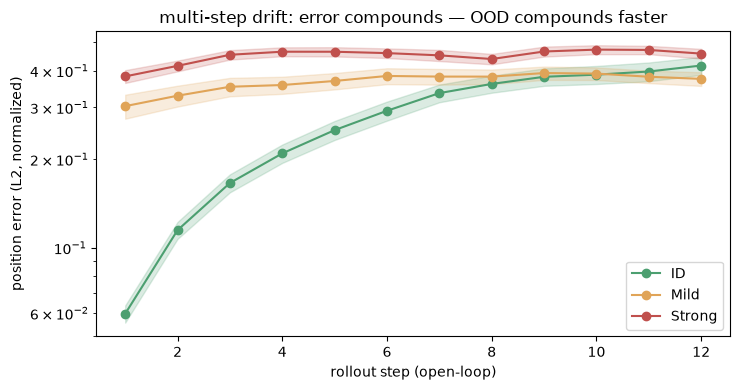

ID       position err  step-1 0.0597 -> step-12 0.4163  (growth ×7.0)   | pixel MSE step-1 0.0094 -> step-12 0.0108 (saturates)
Mild     position err  step-1 0.3029 -> step-12 0.3750  (growth ×1.2)   | pixel MSE step-1 0.0277 -> step-12 0.0272 (saturates)
Strong   position err  step-1 0.3824 -> step-12 0.4571  (growth ×1.2)   | pixel MSE step-1 0.1919 -> step-12 0.1926 (saturates)


In [7]:
HORIZON = 12

def soft_position(img, T=0.1):
    # soft-argmax: weighted centroid of the brightest region of the predicted frame ≈ where the model "thinks" the ball is, (B,1,H,W) -> (B,2)
    b = img.shape[0]
    w = torch.softmax(img.reshape(b, -1) / T, dim=1)
    yy, xx = torch.meshgrid(torch.linspace(0, 1, SIZE), torch.linspace(0, 1, SIZE), indexing="ij")
    return torch.stack([(w * xx.reshape(-1)).sum(1), (w * yy.reshape(-1)).sum(1)], dim=1)

def rollout_eval(data, horizon=HORIZON, n_roll=48, seed=0):
    imgs, acts, _ = prep(data)
    pos = torch.from_numpy(data["positions"]).float()            # hidden true positions (evaluation only)
    cand = np.where(data["ep_ids"][:-horizon] == data["ep_ids"][horizon:])[0]
    starts = np.random.default_rng(seed).choice(cand, size=min(n_roll, len(cand)), replace=False)
    pos_errs, pix_errs = np.zeros((len(starts), horizon)), np.zeros((len(starts), horizon))
    with torch.no_grad():
        for si, s in enumerate(starts):
            z = enc(imgs[s:s + 1])
            for t in range(horizon):
                z = dyn(z, acts[s + t:s + t + 1])                  # eat its own prediction
                img_hat = torch.sigmoid(dec(z))
                pos_errs[si, t] = torch.linalg.norm(soft_position(img_hat)[0] - pos[s + t + 1]).item()
                pix_errs[si, t] = ((img_hat - imgs[s + t + 1]) ** 2).mean().item()
    return starts, pos_errs, pix_errs

rollouts = {c: rollout_eval(eval_data[c]) for c in CONDITIONS}

plt.figure(figsize=(7.5, 4))
for c, color in zip(CONDITIONS, ["#4c9f70", "#e0a458", "#c0504d"]):
    m = rollouts[c][1]
    mu, se = m.mean(0), m.std(0) / np.sqrt(len(m))
    plt.plot(range(1, HORIZON + 1), mu, "o-", color=color, label=c)
    plt.fill_between(range(1, HORIZON + 1), mu - se, mu + se, color=color, alpha=0.2)
plt.xlabel("rollout step (open-loop)"); plt.ylabel("position error (L2, normalized)")
plt.yscale("log")
plt.title("multi-step drift: error compounds — OOD compounds faster")
plt.legend(); plt.tight_layout(); plt.show()

for c in CONDITIONS:
    p, x = rollouts[c][1], rollouts[c][2]
    print(f"{c:7s}  position err  step-1 {p[:, 0].mean():.4f} -> step-{HORIZON} {p[:, -1].mean():.4f}  (growth ×{p[:, -1].mean() / p[:, 0].mean():.1f})"
          f"   | pixel MSE step-1 {x[:, 0].mean():.4f} -> step-{HORIZON} {x[:, -1].mean():.4f} (saturates)")

## 9. Evaluate III — uncertainty proxy: does the model "know" when it is failing?

At deployment we don't get the true error, so we need an **uncertainty proxy** to decide whether to trust a prediction. The cheapest option is **ensemble disagreement** (the PETS / Deep Ensembles idea): train K dynamics nets with different initializations; large disagreement between their predictions = not trustworthy.

Below we quickly train K=5 dynamics nets on the latents of the ID data (seconds), then check: **how strongly does disagreement correlate with the true error?**

ensemble of 5 dynamics nets trained (last loss 42.32505)


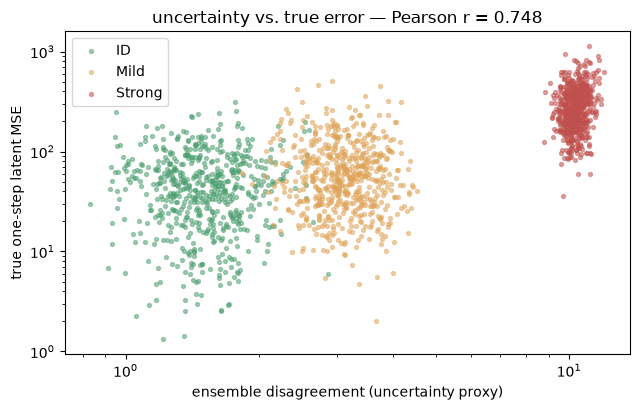

Pearson r (disagreement vs true error, pooled over 3 conditions) = 0.748
ID       mean disagreement 1.53125   mean true error 53.88812
Mild     mean disagreement 3.12882   mean true error 74.18559
Strong   mean disagreement 10.32200   mean true error 296.61725
=> disagreement rises monotonically with shift and correlates positively with the true error: a cheap but useful OOD alarm.


In [8]:
K = 5
with torch.no_grad():
    Z0 = enc(imgs_id[valid_id]); Z1 = enc(imgs_id[valid_id + 1]); A0 = acts_id[valid_id]

ensemble = []
for k in range(K):
    torch.manual_seed(100 + k)
    net = Dynamics()
    opt_k = torch.optim.Adam(net.parameters(), lr=3e-3)
    for step in range(600):
        idx = torch.randint(0, len(Z0), (256,))
        loss_k = mse(net(Z0[idx], A0[idx]), Z1[idx])
        opt_k.zero_grad(); loss_k.backward(); opt_k.step()
    ensemble.append(net.eval())
print(f"ensemble of {K} dynamics nets trained (last loss {loss_k.item():.5f})")

def disagreement_eval(data):
    imgs, acts, valid = prep(data)
    with torch.no_grad():
        z0, z1 = enc(imgs[valid]), enc(imgs[valid + 1])
        preds = torch.stack([m(z0, acts[valid]) for m in ensemble])  # (K, N, z)
        true_err = ((preds.mean(0) - z1) ** 2).mean(dim=1).numpy()   # true error of the ensemble mean
        dis = preds.std(dim=0).mean(dim=1).numpy()                   # ensemble disagreement
    return dis, true_err

unc = {c: disagreement_eval(eval_data[c]) for c in CONDITIONS}
all_dis = np.concatenate([unc[c][0] for c in CONDITIONS])
all_err = np.concatenate([unc[c][1] for c in CONDITIONS])
r = np.corrcoef(all_dis, all_err)[0, 1]

plt.figure(figsize=(6.5, 4.2))
for c, color in zip(CONDITIONS, ["#4c9f70", "#e0a458", "#c0504d"]):
    plt.scatter(unc[c][0], unc[c][1], s=8, alpha=0.5, color=color, label=c)
plt.xscale("log"); plt.yscale("log")
plt.xlabel("ensemble disagreement (uncertainty proxy)")
plt.ylabel("true one-step latent MSE")
plt.title(f"uncertainty vs. true error — Pearson r = {r:.3f}")
plt.legend(); plt.tight_layout(); plt.show()

print(f"Pearson r (disagreement vs true error, pooled over 3 conditions) = {r:.3f}")
for c in CONDITIONS:
    print(f"{c:7s}  mean disagreement {unc[c][0].mean():.5f}   mean true error {unc[c][1].mean():.5f}")
print("=> disagreement rises monotonically with shift and correlates positively with the true error: a cheap but useful OOD alarm.")

## 10. Evaluate IV — prediction error → planning error → policy failure

Finally, close the chain: **plan with a model trained on ID and execute on OOD physics.** The task: drive the ball to the goal position ★.
The planner is the simplest **random shooting** (~12 lines): sample hundreds of candidate action sequences → imagine each one's future with the model → pick the sequence that "in imagination" ends closest to the goal. Execution uses a **receding horizon (MPC style)**: at every step, re-encode the real frame, replan, and execute only the first action.

**Key observation:** the model's imagination is based on ID physics (it doesn't know the world has changed); under ID, MPC basically reaches ★, while under Strong OOD every step overshoots by ×3 and the ball gets stuck to the sticky walls: **policy failure**.

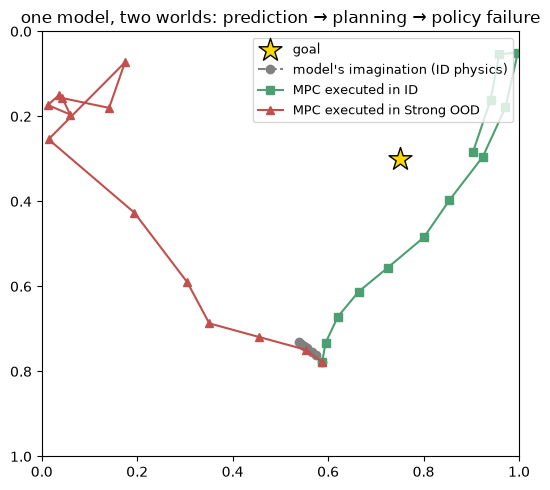

final distance to goal — imagined 0.481 | MPC in ID 0.155 | MPC in Strong OOD 0.729


In [9]:
GOAL = np.array([0.75, 0.30])

def random_shooting(z0, horizon=6, n_samples=768, seed=0):
    cand = torch.randint(-1, 2, (n_samples, horizon, 2),
                         generator=torch.Generator().manual_seed(seed)).float()
    z, cost = z0.repeat(n_samples, 1), torch.zeros(n_samples)
    goal_t = torch.tensor(GOAL, dtype=torch.float32)
    with torch.no_grad():
        for t in range(horizon):
            z = dyn(z, cand[:, t])                                   # imagine one step
            d2 = ((soft_position(torch.sigmoid(dec(z))) - goal_t) ** 2).sum(dim=1)  # where the model "thinks" the ball is
            cost += d2 if t < horizon - 1 else 4 * d2                # extra reward for ending at the goal
    return cand[cost.argmin()]                                       # best imagined sequence

def run_mpc(cond, seed, n_replan=12, horizon=6, n_samples=768):
    world = BallWorld(**CONDITIONS[cond], seed=seed)
    frame = world.reset(seed=seed)
    traj, first_imagined = [world.state[:2].copy()], None
    for t in range(n_replan):
        with torch.no_grad():
            z0 = enc(torch.from_numpy(frame)[None, None])
        plan = random_shooting(z0, horizon, n_samples, seed=seed + t)
        if first_imagined is None:                                   # keep the imagined trajectory of the first plan
            with torch.no_grad():
                z, imagined = z0.clone(), [traj[0]]
                for k in range(horizon):
                    z = dyn(z, plan[k:k + 1])
                    imagined.append(soft_position(torch.sigmoid(dec(z))).numpy()[0])
            first_imagined = np.array(imagined)
        frame = world.step(plan[0].numpy())                          # receding horizon: execute only the first step
        traj.append(world.state[:2].copy())
    return np.array(traj), first_imagined

SEED_PLAN = 7
traj_id, imagined = run_mpc("ID", SEED_PLAN)
traj_strong, _ = run_mpc("Strong", SEED_PLAN)   # same model, same start, same planner

plt.figure(figsize=(5.5, 5))
plt.scatter(*GOAL, marker="*", s=300, c="gold", edgecolors="k", label="goal", zorder=5)
plt.plot(imagined[:, 0], imagined[:, 1], "o--", c="gray", label="model's imagination (ID physics)")
plt.plot(traj_id[:, 0], traj_id[:, 1], "s-", c="#4c9f70", label="MPC executed in ID")
plt.plot(traj_strong[:, 0], traj_strong[:, 1], "^-", c="#c0504d", label="MPC executed in Strong OOD")
plt.xlim(0, 1); plt.ylim(1, 0); plt.legend(loc="upper right", fontsize=9)
plt.title("one model, two worlds: prediction → planning → policy failure")
plt.tight_layout()
plt.savefig("assets/failure_gallery/planning_failure.png", dpi=110, bbox_inches="tight")
plt.show()

d = lambda traj: np.linalg.norm(traj[-1] - GOAL)
print(f"final distance to goal — imagined {d(imagined):.3f} | MPC in ID {d(traj_id):.3f} | MPC in Strong OOD {d(traj_strong):.3f}")

## 11. Failure Gallery: archiving failures

**Why:** a pre-deployment model audit cannot leave behind just one curve. Save the **most typical failure cases** (the rollouts with the largest error, the trajectories where planning failed) with captions into `assets/failure_gallery/`, so you can compare directly after the next model update. The code below automatically picks, for each condition, the rollout with the largest final-step error (top row real frames / bottom row the model's dream), and saves a PNG montage and a caption file.

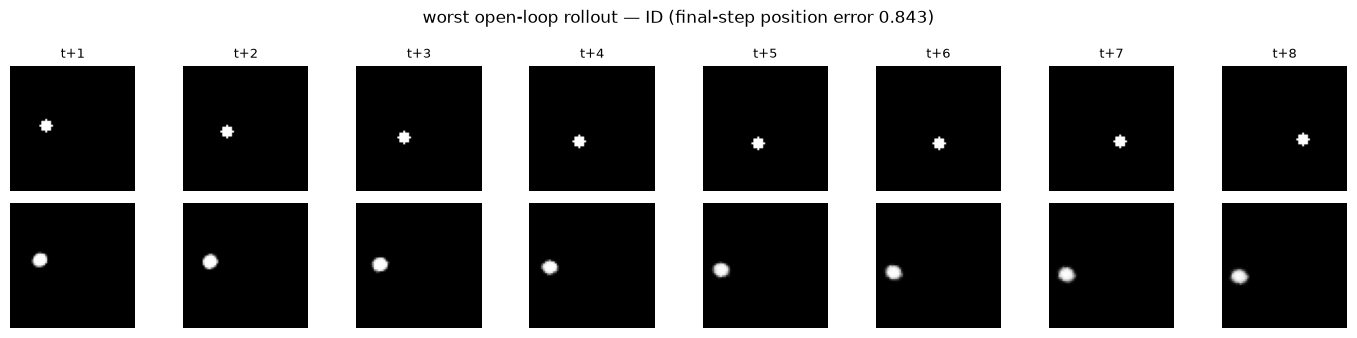

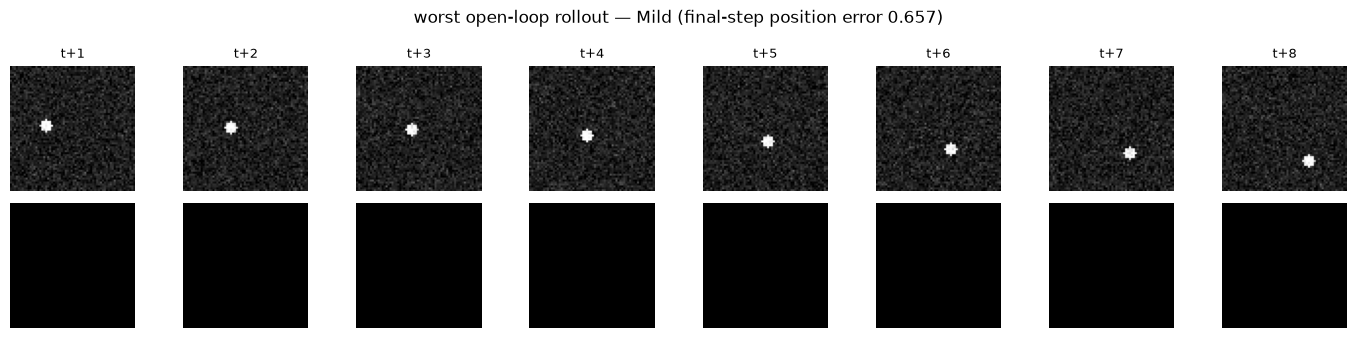

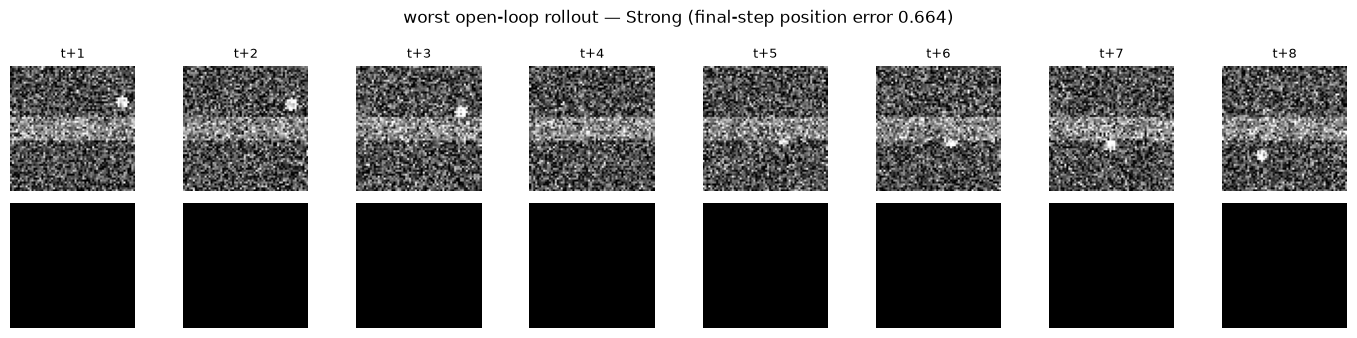

failure_gallery contents:
   captions.txt
   planning_failure.png
   rollout_id.png
   rollout_mild.png
   rollout_strong.png


In [10]:
GAL = "assets/failure_gallery"
SHOW = 8
captions = []

for cond in CONDITIONS:
    starts, pos_errs, _ = rollouts[cond]
    worst = starts[np.argmax(pos_errs[:, -1])]       # rollout with the largest final-step position error
    imgs_c, acts_c, _ = prep(eval_data[cond])
    with torch.no_grad():
        z = enc(imgs_c[worst:worst + 1])
        dream = []
        for t in range(SHOW):
            z = dyn(z, acts_c[worst + t:worst + t + 1])
            dream.append(torch.sigmoid(dec(z))[0, 0].numpy())
    truth = [imgs_c[worst + t + 1, 0].numpy() for t in range(SHOW)]

    fig, axes = plt.subplots(2, SHOW, figsize=(14, 3.4))
    for t in range(SHOW):
        axes[0, t].imshow(truth[t], cmap="gray", vmin=0, vmax=1)
        axes[1, t].imshow(dream[t], cmap="gray", vmin=0, vmax=1)
        for r in range(2):
            axes[r, t].axis("off")
        axes[0, t].set_title(f"t+{t + 1}", fontsize=9)
    axes[0, 0].set_ylabel("truth", rotation=0, labelpad=30)
    axes[1, 0].set_ylabel("dream", rotation=0, labelpad=30)
    plt.suptitle(f"worst open-loop rollout — {cond} (final-step position error {pos_errs[:, -1].max():.3f})")
    plt.tight_layout()
    fname = f"rollout_{cond.lower()}.png"
    plt.savefig(os.path.join(GAL, fname), dpi=110, bbox_inches="tight")
    plt.show()
    captions.append(f"{fname:22s} — {cond} condition: open-loop rollout with the largest final-step position error (top row real frames, bottom row model dream, final position error {pos_errs[:, -1].max():.3f})")

captions.append("planning_failure.png   — planned trajectory (imagined) of the same ID model + random shooting vs the trajectories actually executed under ID / Strong OOD: policy failure under OOD")
with open(os.path.join(GAL, "captions.txt"), "w") as f:
    f.write("Lab 10 Failure Gallery — auto-generated\n" + "=" * 60 + "\n" + "\n".join(captions) + "\n")

print("failure_gallery contents:")
for f_ in sorted(os.listdir(GAL)):
    print("  ", f_)

## 12. Experiment: drift speed sweep

**Guided knob:** change a single parameter, sweeping `speed` from ×1.0 to ×3.0 (everything else stays ID), and compare the position error of the **one-step** prediction and an **8-step rollout** (log scale; dashed line = expected error of a random guess ≈ 0.52).

You will see: the one-step error is only ~0.13 even at ×3, so looking at it alone you'd think the model is "doing fine"; but the 8-step rollout is **already close to chance level on ID**. Multi-step collapse doesn't need OOD; OOD just makes it arrive earlier and more completely.

speed ×1.0   one-step position err 0.0531   8-step rollout position err 0.3332


speed ×1.5   one-step position err 0.0810   8-step rollout position err 0.3972


speed ×2.0   one-step position err 0.0856   8-step rollout position err 0.4319


speed ×2.5   one-step position err 0.1022   8-step rollout position err 0.5149


speed ×3.0   one-step position err 0.1263   8-step rollout position err 0.4650


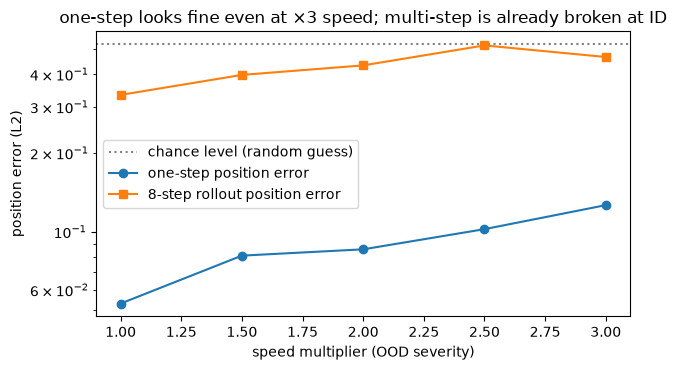

In [11]:
def one_step_pos_err(data):
    imgs, acts, valid = prep(data)
    pos = torch.from_numpy(data["positions"]).float()
    with torch.no_grad():
        pred = soft_position(torch.sigmoid(dec(dyn(enc(imgs[valid]), acts[valid]))))
        return torch.linalg.norm(pred - pos[valid + 1], dim=1).numpy()

sweep = [1.0, 1.5, 2.0, 2.5, 3.0]
curve_1step, curve_8step = [], []
for s in sweep:
    d_s = simulate_dataset(dict(speed=s, friction=0.95, bounce=0.9,
                                obs_noise=0.0, background=0.0, occlude=False),
                           n_ep=24, ep_len=14, seed=300 + int(s * 10))
    curve_1step.append(one_step_pos_err(d_s).mean())
    curve_8step.append(rollout_eval(d_s, horizon=8, n_roll=24)[1][:, -1].mean())
    print(f"speed ×{s:.1f}   one-step position err {curve_1step[-1]:.4f}   8-step rollout position err {curve_8step[-1]:.4f}")

plt.figure(figsize=(6.5, 3.8))
plt.axhline(0.52, ls=":", c="gray", label="chance level (random guess)")
plt.plot(sweep, curve_1step, "o-", label="one-step position error")
plt.plot(sweep, curve_8step, "s-", label="8-step rollout position error")
plt.yscale("log")
plt.xlabel("speed multiplier (OOD severity)"); plt.ylabel("position error (L2)")
plt.title("one-step looks fine even at ×3 speed; multi-step is already broken at ID")
plt.legend(); plt.tight_layout(); plt.show()

## 13. Questions

1. **Why does the one-step error rise only slightly on Mild OOD while the multi-step error gets much worse?** Explain the compounding mechanism in terms of "the error is used as the next step's input".
2. **Blind spots of the uncertainty proxy:** under which kind of shift is ensemble disagreement most reliable? If the OOD lands in a region where all ensemble members are "consistently wrong" (e.g. a systematic bias), does this alarm fail?
3. **Uncertainty-penalized planning:** if the cost became `distance + λ × ensemble disagreement`, would the planner avoid actions where the model is unreliable? How would you design an experiment to check?
4. **Design an OOD shift that fools the current uncertainty proxy** (hint: start from symmetries of the training data / invariances of the encoder).

## 14. Takeaways

- **One-step loss ≠ model quality.** Deployment is about multi-step rollouts: errors compound, the curve grows superlinearly with the horizon, and faster under OOD.
- **Controlled distribution shift is the cheapest robustness experiment.** The same simulator with a different set of physics parameters (speed, friction, bounce, noise, occlusion) gives a graded ID / Mild / Strong OOD evaluation.
- **Ensemble disagreement is a cheap and useful uncertainty proxy** (positively correlated with the true error), but it is not guaranteed to be calibrated, and it has a "consistently wrong" blind spot.
- **Prediction error → planning error → policy failure:** the planner decides based on the model's imagination, so wherever the model is wrong, the planner crashes into it. The end point of evaluating a world model has to be downstream utility.
- **A Failure Gallery should be part of the training pipeline:** quantitative curves + an archive of qualitative failure cases are what let you answer "did it get better?" as the model iterates.
- Following the CIS6280 L23 evaluation framework (accuracy → calibration → robustness → downstream utility), this lab walks the complete loop.

**Next:** more systematic approaches: MPC/CEM with a learned reward, RSSM posterior correction against drift, and uncertainty-triggered human takeover (see [Scientist 12 · OOD & Drift Evaluation](https://overdued.github.io/world-model-spatial-intelligence-course/en/docs/scientist/12-ood-drift-evaluation)).